# Solution 4A: Expanding-Window Backtest
**BUSI 722: Data-Driven Finance II**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from scipy.stats import spearmanr

df = pd.read_parquet("merged.parquet")
df = df[df["month"] >= "2023-01"].copy()

FEATURES = ["momentum", "lag_month", "pb", "roe", "grossmargin",
            "assetturnover", "leverage", "asset_growth", "gp_to_assets"]

for feat in FEATURES:
    df[f"{feat}_rank"] = df.groupby("month")[feat].transform(lambda x: x.rank(pct=True))
df["ret_rank"] = df.groupby("month")["return"].transform(lambda x: x.rank(pct=True))
feat_cols = [f"{f}_rank" for f in FEATURES]
months = sorted(df["month"].unique())
print(f"Data: {len(df):,} rows, {len(months)} months ({months[0]} to {months[-1]})")

Data: 103,931 rows, 35 months (2023-01 to 2025-11)


In [2]:
def run_backtest(df, months, feat_cols, start_month="2024-01", window=None):
    start_idx = next(i for i, m in enumerate(months) if m >= start_month)
    all_preds = []
    for t in range(start_idx, len(months)):
        test_month = months[t]
        if window is None:
            train_data = df[df["month"] < test_month]
        else:
            train_start_idx = max(0, t - window)
            train_months = months[train_start_idx:t]
            train_data = df[df["month"].isin(train_months)]
        test_data = df[df["month"] == test_month]
        if len(train_data) < 100 or len(test_data) < 10:
            continue
        model = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, max_depth=6,
                                  random_state=42, verbosity=-1, n_jobs=-1)
        model.fit(train_data[feat_cols].values, train_data["ret_rank"].values)
        result = test_data[["ticker", "month", "return", "ret_rank", "marketcap"]].copy()
        result["pred"] = model.predict(test_data[feat_cols].values)
        all_preds.append(result)
        print(f"  Predicted {test_month} (train: {len(train_data):,} rows)")
    return pd.concat(all_preds, ignore_index=True)

## 1-2. Run expanding-window backtest

In [3]:
preds_exp = run_backtest(df, months, feat_cols, start_month="2024-01", window=None)
print(f"\nPredictions: {len(preds_exp):,} stock-months")

preds_exp["decile"] = preds_exp.groupby("month")["pred"].transform(
    lambda x: pd.qcut(x, 10, labels=False, duplicates="drop") + 1
)

  Predicted 2024-01 (train: 37,810 rows)


  Predicted 2024-02 (train: 40,875 rows)


  Predicted 2024-03 (train: 43,892 rows)


  Predicted 2024-04 (train: 46,935 rows)


  Predicted 2024-05 (train: 49,980 rows)


...

  Predicted 2025-07 (train: 90,254 rows)


  Predicted 2025-08 (train: 92,989 rows)


  Predicted 2025-09 (train: 95,708 rows)


  Predicted 2025-10 (train: 98,458 rows)


  Predicted 2025-11 (train: 101,205 rows)

Predictions: 66,121 stock-months


## 3-4. Decile returns and Sharpe ratios

In [4]:
dec_ret = preds_exp.groupby(["month", "decile"])["return"].mean().reset_index()
dec_avg = dec_ret.groupby("decile")["return"].mean()
dec_std = dec_ret.groupby("decile")["return"].std()

print(f"{'Decile':>8s} {'Mean':>10s} {'Ann. Sharpe':>12s}")
print("-" * 32)
for d in sorted(dec_avg.index):
    sr = dec_avg[d] / dec_std[d] * np.sqrt(12) if dec_std[d] > 0 else 0
    print(f"  D{int(d):2d}    {dec_avg[d]:10.4f} {sr:12.3f}")

pivot = dec_ret.pivot(index="month", columns="decile", values="return").sort_index()
ls = pivot[pivot.columns.max()] - pivot[pivot.columns.min()]
ls_sr = ls.mean() / ls.std() * np.sqrt(12) if ls.std() > 0 else 0
print(f"\n  D10-D1: mean={ls.mean():.4f}, ann. Sharpe={ls_sr:.3f}")

  Decile       Mean  Ann. Sharpe
--------------------------------
  D 1       -0.0348       -1.961
  D 2        0.0064        0.404
  D 3        0.0068        0.449
  D 4        0.0066        0.514
  D 5        0.0069        0.576
  D 6        0.0072        0.644
  D 7        0.0095        0.807
  D 8        0.0088        0.756
  D 9        0.0105        0.816
  D10        0.0150        0.935

  D10-D1: mean=0.0497, ann. Sharpe=2.723


## 5. Cumulative returns plot

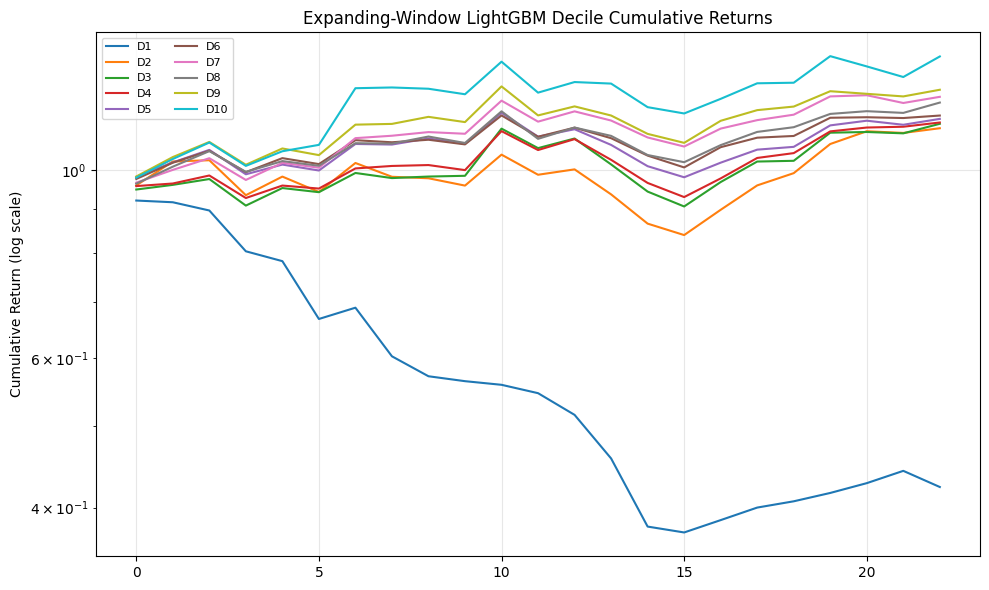

Saved: expanding_predictions.parquet


In [5]:
cumulative = (1 + pivot).cumprod()
fig, ax = plt.subplots(figsize=(10, 6))
for col in cumulative.columns:
    ax.plot(range(len(cumulative)), cumulative[col], label=f"D{int(col)}")
ax.set_yscale("log")
ax.set_title("Expanding-Window LightGBM Decile Cumulative Returns")
ax.set_ylabel("Cumulative Return (log scale)")
ax.legend(ncol=2, fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Save for later exercises
preds_exp.to_parquet("expanding_predictions.parquet", index=False)
print("Saved: expanding_predictions.parquet")